In [2]:
import torch

In [3]:
torch.__version__

'2.10.0+cu128'

In [5]:
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor ,Lambda,Compose
import matplotlib.pyplot as plt

In [12]:
##Download the train data
trainning_data=datasets.FashionMNIST(
    root = "data",
    train = True,
    download = True,
    transform = ToTensor()
)

In [13]:
##Download the test data
test_data=datasets.FashionMNIST(
    root = "data",
    train = False,
    download = True,
    transform = ToTensor()
)

In [14]:
batch_size=64
DataLoader_train=DataLoader(trainning_data,batch_size=batch_size)
Dataloader_test=DataLoader(test_data,batch_size=batch_size)

In [16]:
Dataloader_test

In [19]:
for x,y in Dataloader_test:
    print(x,y)

Streaming output truncated to the last 5000 lines.
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]]],


        [[[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          ...,
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]]],


        ...,


        [[[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          ...,
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..

In [20]:
for x,y in Dataloader_test:
    print(y)

tensor([9, 2, 1, 1, 6, 1, 4, 6, 5, 7, 4, 5, 7, 3, 4, 1, 2, 4, 8, 0, 2, 5, 7, 9,
        1, 4, 6, 0, 9, 3, 8, 8, 3, 3, 8, 0, 7, 5, 7, 9, 6, 1, 3, 7, 6, 7, 2, 1,
        2, 2, 4, 4, 5, 8, 2, 2, 8, 4, 8, 0, 7, 7, 8, 5])
tensor([1, 1, 2, 3, 9, 8, 7, 0, 2, 6, 2, 3, 1, 2, 8, 4, 1, 8, 5, 9, 5, 0, 3, 2,
        0, 6, 5, 3, 6, 7, 1, 8, 0, 1, 4, 2, 3, 6, 7, 2, 7, 8, 5, 9, 9, 4, 2, 5,
        7, 0, 5, 2, 8, 6, 7, 8, 0, 0, 9, 9, 3, 0, 8, 4])
tensor([1, 5, 4, 1, 9, 1, 8, 6, 2, 1, 2, 5, 1, 0, 0, 0, 1, 6, 1, 6, 2, 2, 4, 4,
        1, 4, 5, 0, 4, 7, 9, 3, 7, 2, 3, 9, 0, 9, 4, 7, 4, 2, 0, 5, 2, 1, 2, 1,
        3, 0, 9, 1, 0, 9, 3, 6, 7, 9, 9, 4, 4, 7, 1, 2])
tensor([1, 6, 3, 2, 8, 3, 6, 1, 1, 0, 2, 9, 2, 4, 0, 7, 9, 8, 4, 1, 8, 4, 1, 3,
        1, 6, 7, 2, 8, 5, 2, 0, 7, 7, 6, 2, 7, 0, 7, 8, 9, 2, 9, 0, 5, 1, 4, 4,
        5, 6, 9, 2, 6, 8, 6, 4, 2, 2, 9, 7, 6, 5, 5, 2])
tensor([8, 5, 2, 3, 0, 4, 8, 0, 0, 6, 3, 8, 9, 6, 1, 3, 0, 2, 3, 0, 8, 3, 7, 4,
        0, 1, 6, 3, 0, 6, 6, 7, 5, 4, 5, 9, 5, 6, 5,

In [21]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using {device} device")


Using cuda device


In [23]:
if device == "cuda":
    print(torch.version.cuda)
else:
    print("CUDA is not available.")

12.8


In [26]:
##define our custom nn
class NeuralNetworks(nn.Module):
    def __init__(self):
        super(NeuralNetworks,self).__init__()
        self.flatten=nn.Flatten()
        self.linear_relu_stack=nn.Sequential(
            nn.Linear(28*28,512),
            nn.ReLU(),
            nn.Linear(512,512),
            nn.ReLU(),
            nn.Linear(512,10)
        )

    def forward(self,x):
        x=self.flatten(x)
        logits=self.linear_relu_stack(x)
        return logits

In [27]:
device

'cuda'

In [28]:
model=NeuralNetworks().to(device)
model

NeuralNetworks(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=10, bias=True)
  )
)

In [29]:
loss_function=nn.CrossEntropyLoss()
optimizer=torch.optim.SGD(model.parameters(),lr=1e-3)

In [40]:
## train loop

def train(dataloader, model, loss_fn, optimizer):
  size = len(dataloader.dataset)
  model.train()
  for batch, (x, y) in enumerate(dataloader):
    x, y = x.to(device), y.to(device)

    # Compute prediction error
    pred = model(x)
    loss = loss_fn(pred, y)

    # Backpropagation
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if batch % 100 == 0:
      loss, current = loss.item(), batch * len(x)
      print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")

In [38]:
##testing loop
def test(dataloader, model, loss_fn):
  size = len(dataloader.dataset)
  num_batches = len(dataloader)
  model.eval()
  test_loss, correct = 0, 0
  with torch.no_grad():
    for X, y in dataloader:
      X, y = X.to(device), y.to(device)
      pred = model(X)
      test_loss += loss_fn(pred, y).item()
      correct += (pred.argmax(1) == y).type(torch.float).sum().item()
  test_loss /= num_batches
  correct /= size
  print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")

In [42]:
##start trainning
epochs = 25
for t in range(epochs):
  print(f"Epoch {t+1}\n-------------------------------")
  train(DataLoader_train, model, loss_function, optimizer)
  test(Dataloader_test, model, loss_function)

print("Done!")

Epoch 1
-------------------------------
loss: 0.643822  [    0/60000]
loss: 0.744412  [ 6400/60000]
loss: 0.510250  [12800/60000]
loss: 0.749926  [19200/60000]
loss: 0.674082  [25600/60000]
loss: 0.641444  [32000/60000]
loss: 0.718849  [38400/60000]
loss: 0.711605  [44800/60000]
loss: 0.712123  [51200/60000]
loss: 0.680389  [57600/60000]
Test Error: 
 Accuracy: 76.4%, Avg loss: 0.672944 

Epoch 2
-------------------------------
loss: 0.621954  [    0/60000]
loss: 0.723950  [ 6400/60000]
loss: 0.493291  [12800/60000]
loss: 0.736240  [19200/60000]
loss: 0.661266  [25600/60000]
loss: 0.629711  [32000/60000]
loss: 0.701208  [38400/60000]
loss: 0.701840  [44800/60000]
loss: 0.700262  [51200/60000]
loss: 0.666573  [57600/60000]
Test Error: 
 Accuracy: 77.0%, Avg loss: 0.658753 

Epoch 3
-------------------------------
loss: 0.602281  [    0/60000]
loss: 0.705216  [ 6400/60000]
loss: 0.478231  [12800/60000]
loss: 0.723557  [19200/60000]
loss: 0.649686  [25600/60000]
loss: 0.619467  [32000/600

In [43]:
##Save model
torch.save(model.state_dict(), "model.pth")
print("Saved PyTorch Model State to model.pth")

Saved PyTorch Model State to model.pth


In [44]:
##load model
model = NeuralNetworks()
model.load_state_dict(torch.load("model.pth"))

<All keys matched successfully>

In [45]:
##prediction classes

classes={
    0:'T-shirt/top',
    1:'Trouser',
    2:'Pullover',
    3:'Dress',
    4:'Coat',
    5:'Sandal',
    6:'Shirt',
    7:'Sneaker',
    8:'Bag',
    9:'Ankle boot'
}


In [46]:
len(classes)

10

In [49]:
x,y = test_data[0][0],test_data[0][1]
x

tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,

In [50]:
y

9

In [55]:
with torch.no_grad():
  pred = model(x)
  predicted, actual = classes[pred[0].argmax(0).item()], classes[y]
  print(f'Predicted: "{predicted}", Actual: "{actual}"')


Predicted: "Ankle boot", Actual: "Ankle boot"


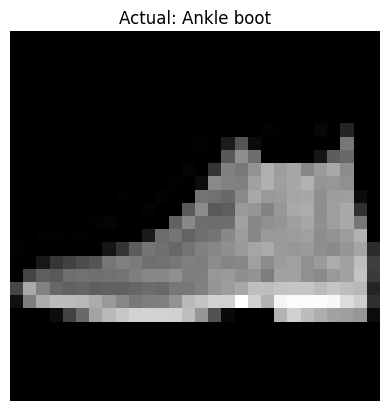

In [56]:
plt.imshow(x[0], cmap='gray')
plt.title(f"Actual: {classes[y]}")
plt.axis('off')
plt.show()

In [57]:
from google.colab import files

# Download the trained model weights
files.download('model.pth')

print("To download the notebook, go to File > Download > Download .ipynb")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

To download the notebook, go to File > Download > Download .ipynb
